In [1]:
import pandas as pd

df = pd.read_csv("dataset_malwares.csv")

print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df['Malware'].value_counts())

(19611, 79)
                                          Name  e_magic  e_cblp  e_cp  e_crlc  \
0  VirusShare_a878ba26000edaac5c98eff4432723b3    23117     144     3       0   
1  VirusShare_ef9130570fddc174b312b2047f5f4cf0    23117     144     3       0   
2  VirusShare_ef84cdeba22be72a69b198213dada81a    23117     144     3       0   
3  VirusShare_6bf3608e60ebc16cbcff6ed5467d469e    23117     144     3       0   
4  VirusShare_2cc94d952b2efb13c7d6bbe0dd59d3fb    23117     144     3       0   

   e_cparhdr  e_minalloc  e_maxalloc  e_ss  e_sp  ...  SectionMaxChar  \
0          4           0       65535     0   184  ...      3758096608   
1          4           0       65535     0   184  ...      3791650880   
2          4           0       65535     0   184  ...      3221225536   
3          4           0       65535     0   184  ...      3224371328   
4          4           0       65535     0   184  ...      3227516992   

   SectionMainChar  DirectoryEntryImport  DirectoryEntryImport

In [2]:
df.drop(columns=['Name'], inplace=True)

In [3]:
X = df.drop(columns=['Malware'])
y = df['Malware']

print(y)

0        1
1        1
2        1
3        1
4        1
        ..
19606    0
19607    0
19608    0
19609    0
19610    0
Name: Malware, Length: 19611, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [11]:
import joblib

# Save Random Forest
joblib.dump(rf_model, "models/random_forest.pkl")

# Save XGBoost  ← THIS IS WHAT WAS MISSING
joblib.dump(xgb_model, "models/xgb_model.pkl")

# Save feature columns
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "models/feature_columns.pkl")

print("All models saved successfully.")
print(f"Feature columns saved: {len(feature_columns)} features")

All models saved successfully.
Feature columns saved: 77 features


In [12]:
# RF metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest Results
Accuracy : 0.9908233494774408
Precision: 0.989145183175034
Recall   : 0.9986301369863013
F1 Score : 0.9938650306748467


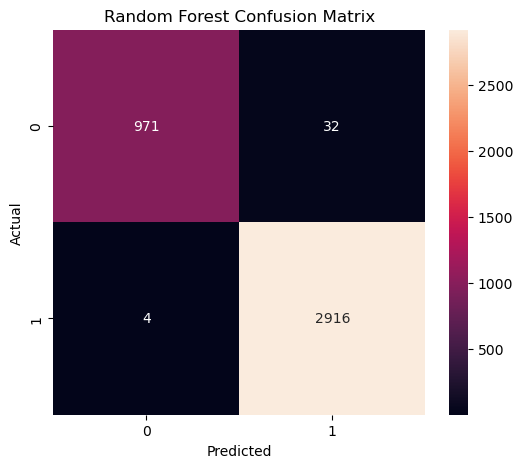

In [13]:
# RF confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

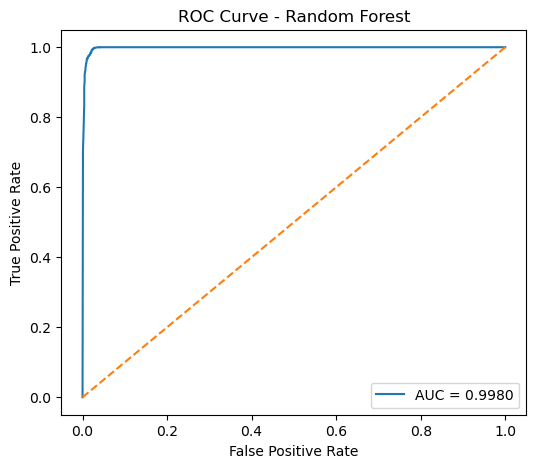

In [17]:
# RF roc
from sklearn.metrics import roc_curve, auc

y_probs = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

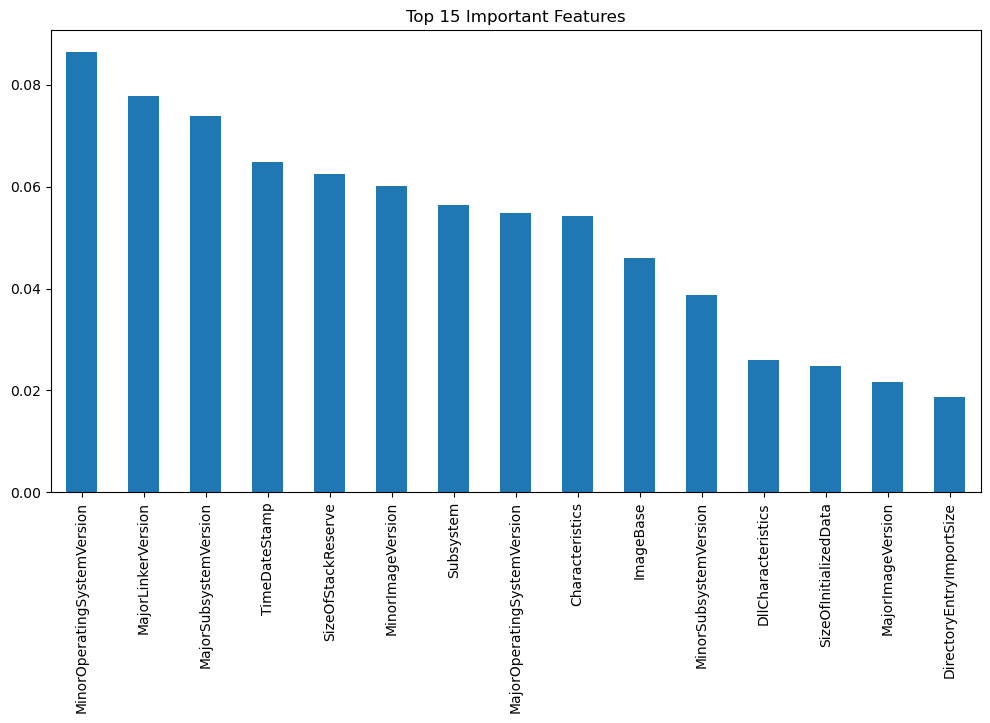

In [16]:
# rf feature importance

import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(12,6))
importance.head(15).plot(kind='bar')
plt.title("Top 15 Important Features")
plt.show()

In [18]:
# XGB metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

XGBoost Results
Accuracy : 0.9923527912312006
Precision: 0.9904955872369314
Recall   : 0.9993150684931507
F1 Score : 0.9948857824752813


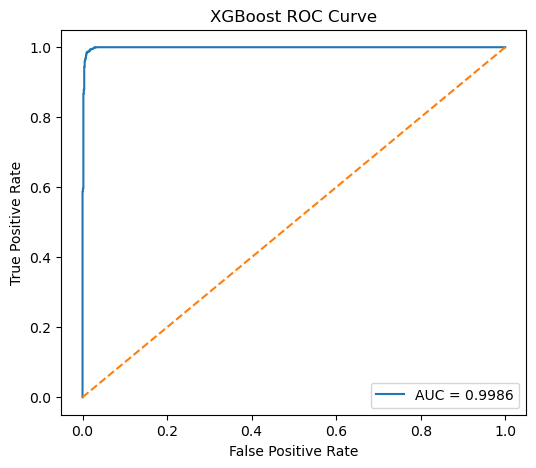

In [19]:
#  XGB roc
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs_xgb = xgb_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

In [20]:
# model comparision
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

print(comparison)

           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.990823   0.989145  0.998630  0.993865
1        XGBoost  0.992353   0.990496  0.999315  0.994886


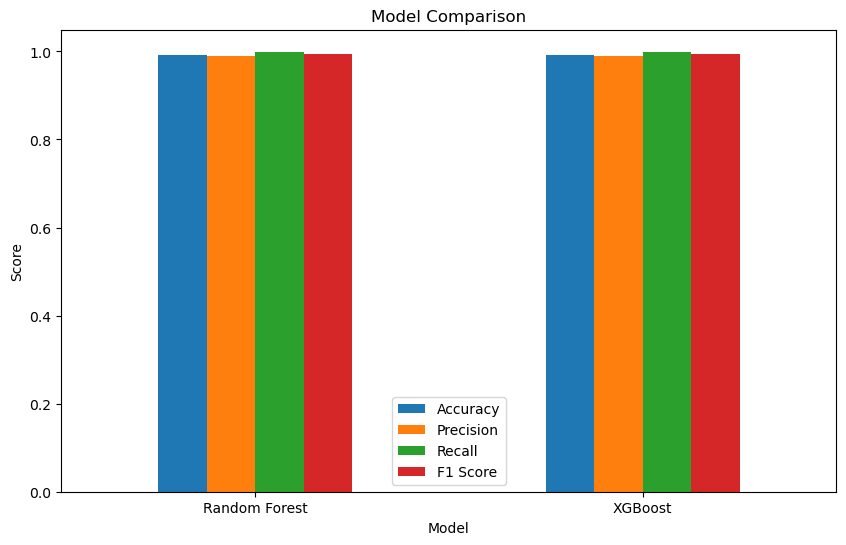

In [22]:
# graph for comparision

import matplotlib.pyplot as plt

comparison.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [25]:
import joblib
import pandas as pd
from script.feature_extractor import extract_features

# Load both models and feature columns
rf_model_loaded   = joblib.load("models/random_forest.pkl")
xgb_model_loaded  = joblib.load("models/xgb_model.pkl")   # ← now works
feature_columns   = joblib.load("models/feature_columns.pkl")

# Extract features from exe
features = extract_features("script/sf-x64.exe")

df_exe = pd.DataFrame([features])
for col in feature_columns:
    if col not in df_exe.columns:
        df_exe[col] = 0
df_exe = df_exe[feature_columns]

# Predict with both
for name, model in [("Random Forest", rf_model_loaded), ("XGBoost", xgb_model_loaded)]:
    prediction  = model.predict(df_exe)[0]
    probability = model.predict_proba(df_exe)[0][1]
    label       = "Malware Detected" if prediction == 1 else "Benign File"
    confidence  = probability * 100 if prediction == 1 else (1 - probability) * 100
    print(f"[{name}] {label} | Confidence: {confidence:.2f}%")

[Random Forest] Benign File | Confidence: 68.00%
[XGBoost] Benign File | Confidence: 99.41%


In [26]:
import joblib
from script.feature_extractor import extract_features

feature_columns = joblib.load("models/feature_columns.pkl")
features = extract_features("script/sf-x64.exe")

print(len(features))

missing = [col for col in feature_columns if col not in features]
print("Missing Features:", len(missing))
print(missing)

77
Missing Features: 0
[]
